# Check: ensemble loss (`plot_losses_ensemble`)

Plots the **training and validation loss over the whole replica ensemble** as a
central value with an uncertainty band (one figure), as opposed to
`plot_losses_all_replicas`, which draws one curve per replica.

The band convention is chosen by parameters that mirror the shared `draw_bounds`
primitive:
- `central_value`: `"mean"` or `"median"`,
- `show_std`: shade central value $\pm$ 1 standard deviation,
- `show_68`: draw the 68% interval edges (dashed).

The report (`analysis.yaml`) currently sets central value $\pm$ 1 std; below we
show that default and the mean + 68% alternative.

Note: building `loss_function_grid` predicts the PDF at every stored epoch, so it
can be slow. Pass `custom_epochs=[...]` (epochs with saved weights) to limit it.

In [1]:
%matplotlib inline
from IPython.display import display

from ntkpdf.api import API

import logging
logging.basicConfig(level=logging.INFO)

Applying NTKPDF plotting style...
Using Keras backend


In [2]:
# Minimal data/theory context the FK chain behind loss_function_grid needs.
common_dict = dict(
    dataset_inputs={"from_": "fit"},
    use_cuts="fromfit",
    theory={"from_": "fit"},
    theoryid={"from_": "theory"},
)
fit = "260527-ac-01-ntk-sgd"

INFO:ntkpdf.config:Building base PDF model for 3 replicas.
INFO:2026-06-09 21:09:06,228:jax._src.xla_bridge:812: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.

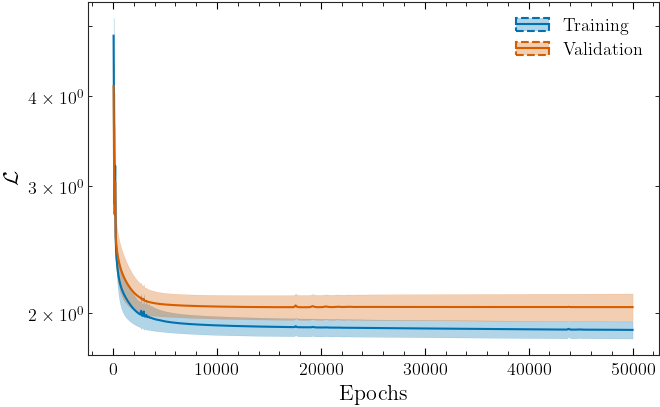

In [3]:
# Default convention used in the report: central value (mean) +/- 1 std.
fig = API.plot_losses_ensemble(
    fit=fit,
    **common_dict,
    central_value="mean",
    show_std=True,
    show_68=False,
    yscale="log",
    custom_epochs=[500, 1000, 2000, 5000],
)
display(fig)

INFO:ntkpdf.config:Building base PDF model for 3 replicas.
/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


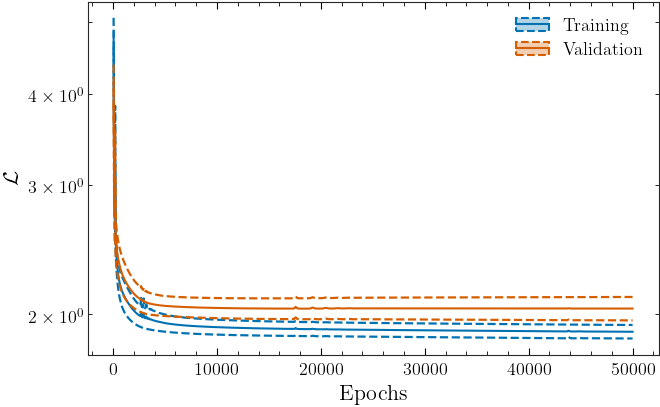

In [4]:
# Alternative convention: mean with the 68% interval edges (dashed) instead of std.
fig = API.plot_losses_ensemble(
    fit=fit,
    **common_dict,
    central_value="mean",
    show_std=False,
    show_68=True,
    yscale="log",
    custom_epochs=[500, 1000, 2000, 5000],
)
display(fig)